<a href="https://colab.research.google.com/github/sravanmalla123/Data-Cleaning-Preprocessing/blob/main/Support_Vector_Machines_(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Support Vector Machines (SVMs) for Linear Classification

First, we'll demonstrate a Linear SVM on a simple linearly separable dataset.

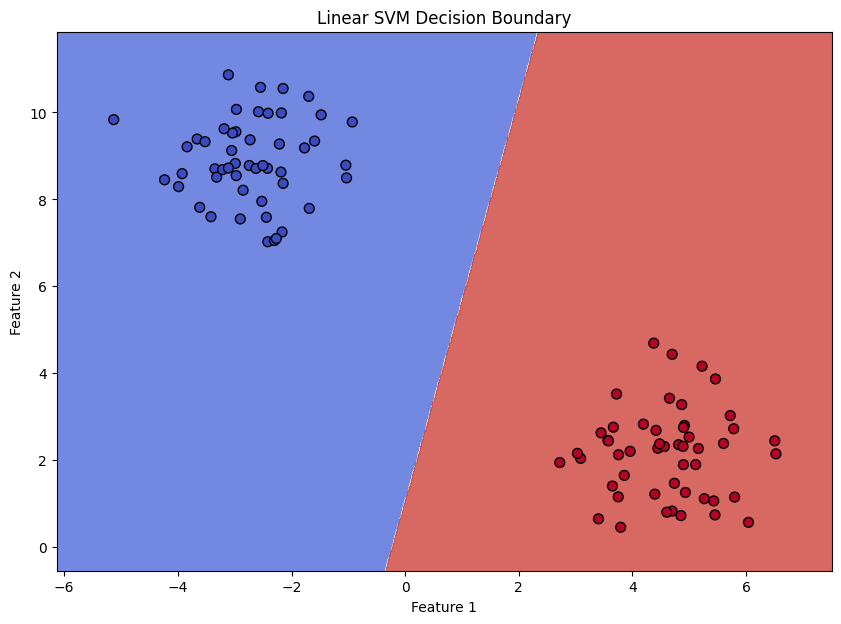

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.datasets import make_blobs

# Generate a linearly separable dataset
X, y = make_blobs(n_samples=100,
                  centers=2,
                  random_state=42,
                  cluster_std=1.0)

# Train a Linear SVM model
# The 'hinge' loss is the standard SVM loss.
# 'max_iter' is increased to ensure convergence for some datasets.
# 'dual=False' is preferred when n_samples > n_features, which is often the case.
# Changed 'hinge' loss to 'squared_hinge' to be compatible with dual=False
model = LinearSVC(loss='squared_hinge', dual=False, random_state=42, max_iter=10000)
model.fit(X, y)

# Create a mesh to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid to get decision boundaries
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear SVM Decision Boundary')
plt.show()